In [85]:
import pandas as pd

df = pd.read_csv("../dataset/data.csv", encoding='latin-1')
df_uk = df[df['Country'] == 'United Kingdom']
# print(len(df_uk))

df_uk.to_csv("../dataset/data_uk.csv", index=False)

In [86]:
df_uk = df_uk.copy()

temp_date = pd.to_datetime(df_uk['InvoiceDate'], format='%m/%d/%Y %H:%M', errors='coerce')
invalid_dates = temp_date.isna().sum()
print(f"Sai định dạng thời gian: {invalid_dates}")

print("\nGiá trị thiếu:")
print(df_uk.isnull().sum())

print("\nGiá trị âm:")
print("Quantity\t", (df_uk['Quantity'] < 0).sum())
print("UnitPrice\t", (df_uk['UnitPrice'] < 0).sum())

Sai định dạng thời gian: 0

Giá trị thiếu:
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     133600
Country             0
dtype: int64

Giá trị âm:
Quantity	 9192
UnitPrice	 2


In [87]:
df_uk = df_uk.copy()

df_uk['InvoiceNo'] = df_uk['InvoiceNo'].astype(str)
df_uk['Description'] = df_uk['Description'].astype(str).str.lower()

bad_keywords = ['postage', 'dotcom', 'nan', 'wrongly marked', 
                'amazon fee', 'manual', 'check', 'adjustment',
                'samples', 'damaged', 'found', 'thrown away',
                'lost']

df_cleaned = df_uk[
    (df_uk['UnitPrice'] > 0) & 
    ~((df_uk['Quantity'] <= 0) & (~df_uk['InvoiceNo'].str.startswith('C'))) & # Bỏ những dòng có số lượng âm 
                                                                              # nhưng mã hóa đơn không bắt đầu bằng 'C'
    ~(df_uk['Description'].str.contains('|'.join(bad_keywords), case=False, na=False))
]

df_cleaned.to_csv('../dataset/uk_cleaned.csv', index=False)

In [88]:
df = pd.read_csv('../dataset/uk_cleaned.csv', low_memory=False)
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

df_filtered = df.copy()

weekly_summary = df_filtered.groupby([
    'StockCode',
    pd.Grouper(key='InvoiceDate', freq='W-MON', closed='left', label='left') # Thứ Hai là ngày bắt đầu tuần
])['Quantity'].sum().unstack(fill_value=0)

weekly_summary['Total_Quantity'] = weekly_summary.sum(axis=1)
weekly_summary = weekly_summary.sort_values(by='Total_Quantity', ascending=False)

num_weeks = weekly_summary.columns.size - 1
weekly_summary.columns = [f'{i+1}' for i in range(num_weeks)] + ['Total_Quantity']

weekly_summary.to_csv(f'../dataset/quantity_weekly.csv')

In [89]:
# 50 sản phẩm trang trí nhà cửa bán chạy nhất
# home_decor_stockcodes = [
#     '22961', '21181', '21137', '84978', '21326', '22969', '79321', '84945', 
#     '84992', '22577', '22470', '21175', '22578', '21166', '22457', '82482', 
#     '23307', '84970S', '85152', '22865', '22791', '23298', '21733', '75049L', 
#     '82583', '22666', '22727', '22866', '22090', '82494L', '22867', '82600', 
#     '22726', '72741', '40016', '71477', '21810', '84836', '21231', '84970L', 
#     '85175', '22147', '82580', '22294', '22722', '22161', '21811', '23321', 
#     '22834', '84949'
# ]

# Các sản phẩm còn lại sau khi loại trừ các sản phẩm có chuỗi thời gian khó học hoặc kém ý nghĩa 
home_decor_stockcodes = [
    '22961', '21181', '21137', '84978', '21326', '22969', '79321',
    '84992', '22470', '21175', '21166', '22457', '82482', '84945',
    '23307', '84970S', '85152', '22791', '23298', '21733', '75049L',
    '82583', '22666', '22727', '22090', '82494L', '82600', '84949',
    '22726', '72741', '40016', '71477', '84836', '21231', '84970L',
    '85175', '22147', '82580', '22294', '22722', '22161', '22469',
    '22403', '84992' # Hai sản phẩm thay thế doanh số cho 18 tuần đầu tiên của lần lượt các sp 23298, 23307
]

In [90]:
df_quantity = pd.read_csv('../dataset/quantity_weekly.csv', low_memory=False)

df_decor_all = df_quantity[df_quantity['StockCode'].isin(home_decor_stockcodes)]
df_decor_top50 = df_decor_all.nlargest(100, 'Total_Quantity')

df_decor_top50.drop(columns=['Total_Quantity']).to_csv('../dataset/quantity_weekly_decor.csv', index=False)

In [92]:
import matplotlib.pyplot as plt

df = pd.read_csv("../dataset/quantity_weekly_decor.csv")

df_melted = df.melt(id_vars=['StockCode'], var_name='Week', value_name='Quantity')

# Tạo dãy ngày bắt đầu từ 2010-12-01 (mỗi tuần một lần)
# Tạo dictionary để map Week_1 -> 2010-12-01, Week_2 -> 2010-12-08...
weeks = [f'{i}' for i in range(1, 54)]
dates = pd.date_range(start='2010-12-01', periods=53, freq='W')
date_map = dict(zip(weeks, dates))

df_melted['Date'] = df_melted['Week'].map(date_map)
ts_data = df_melted.pivot(index='Date', columns='StockCode', values='Quantity')

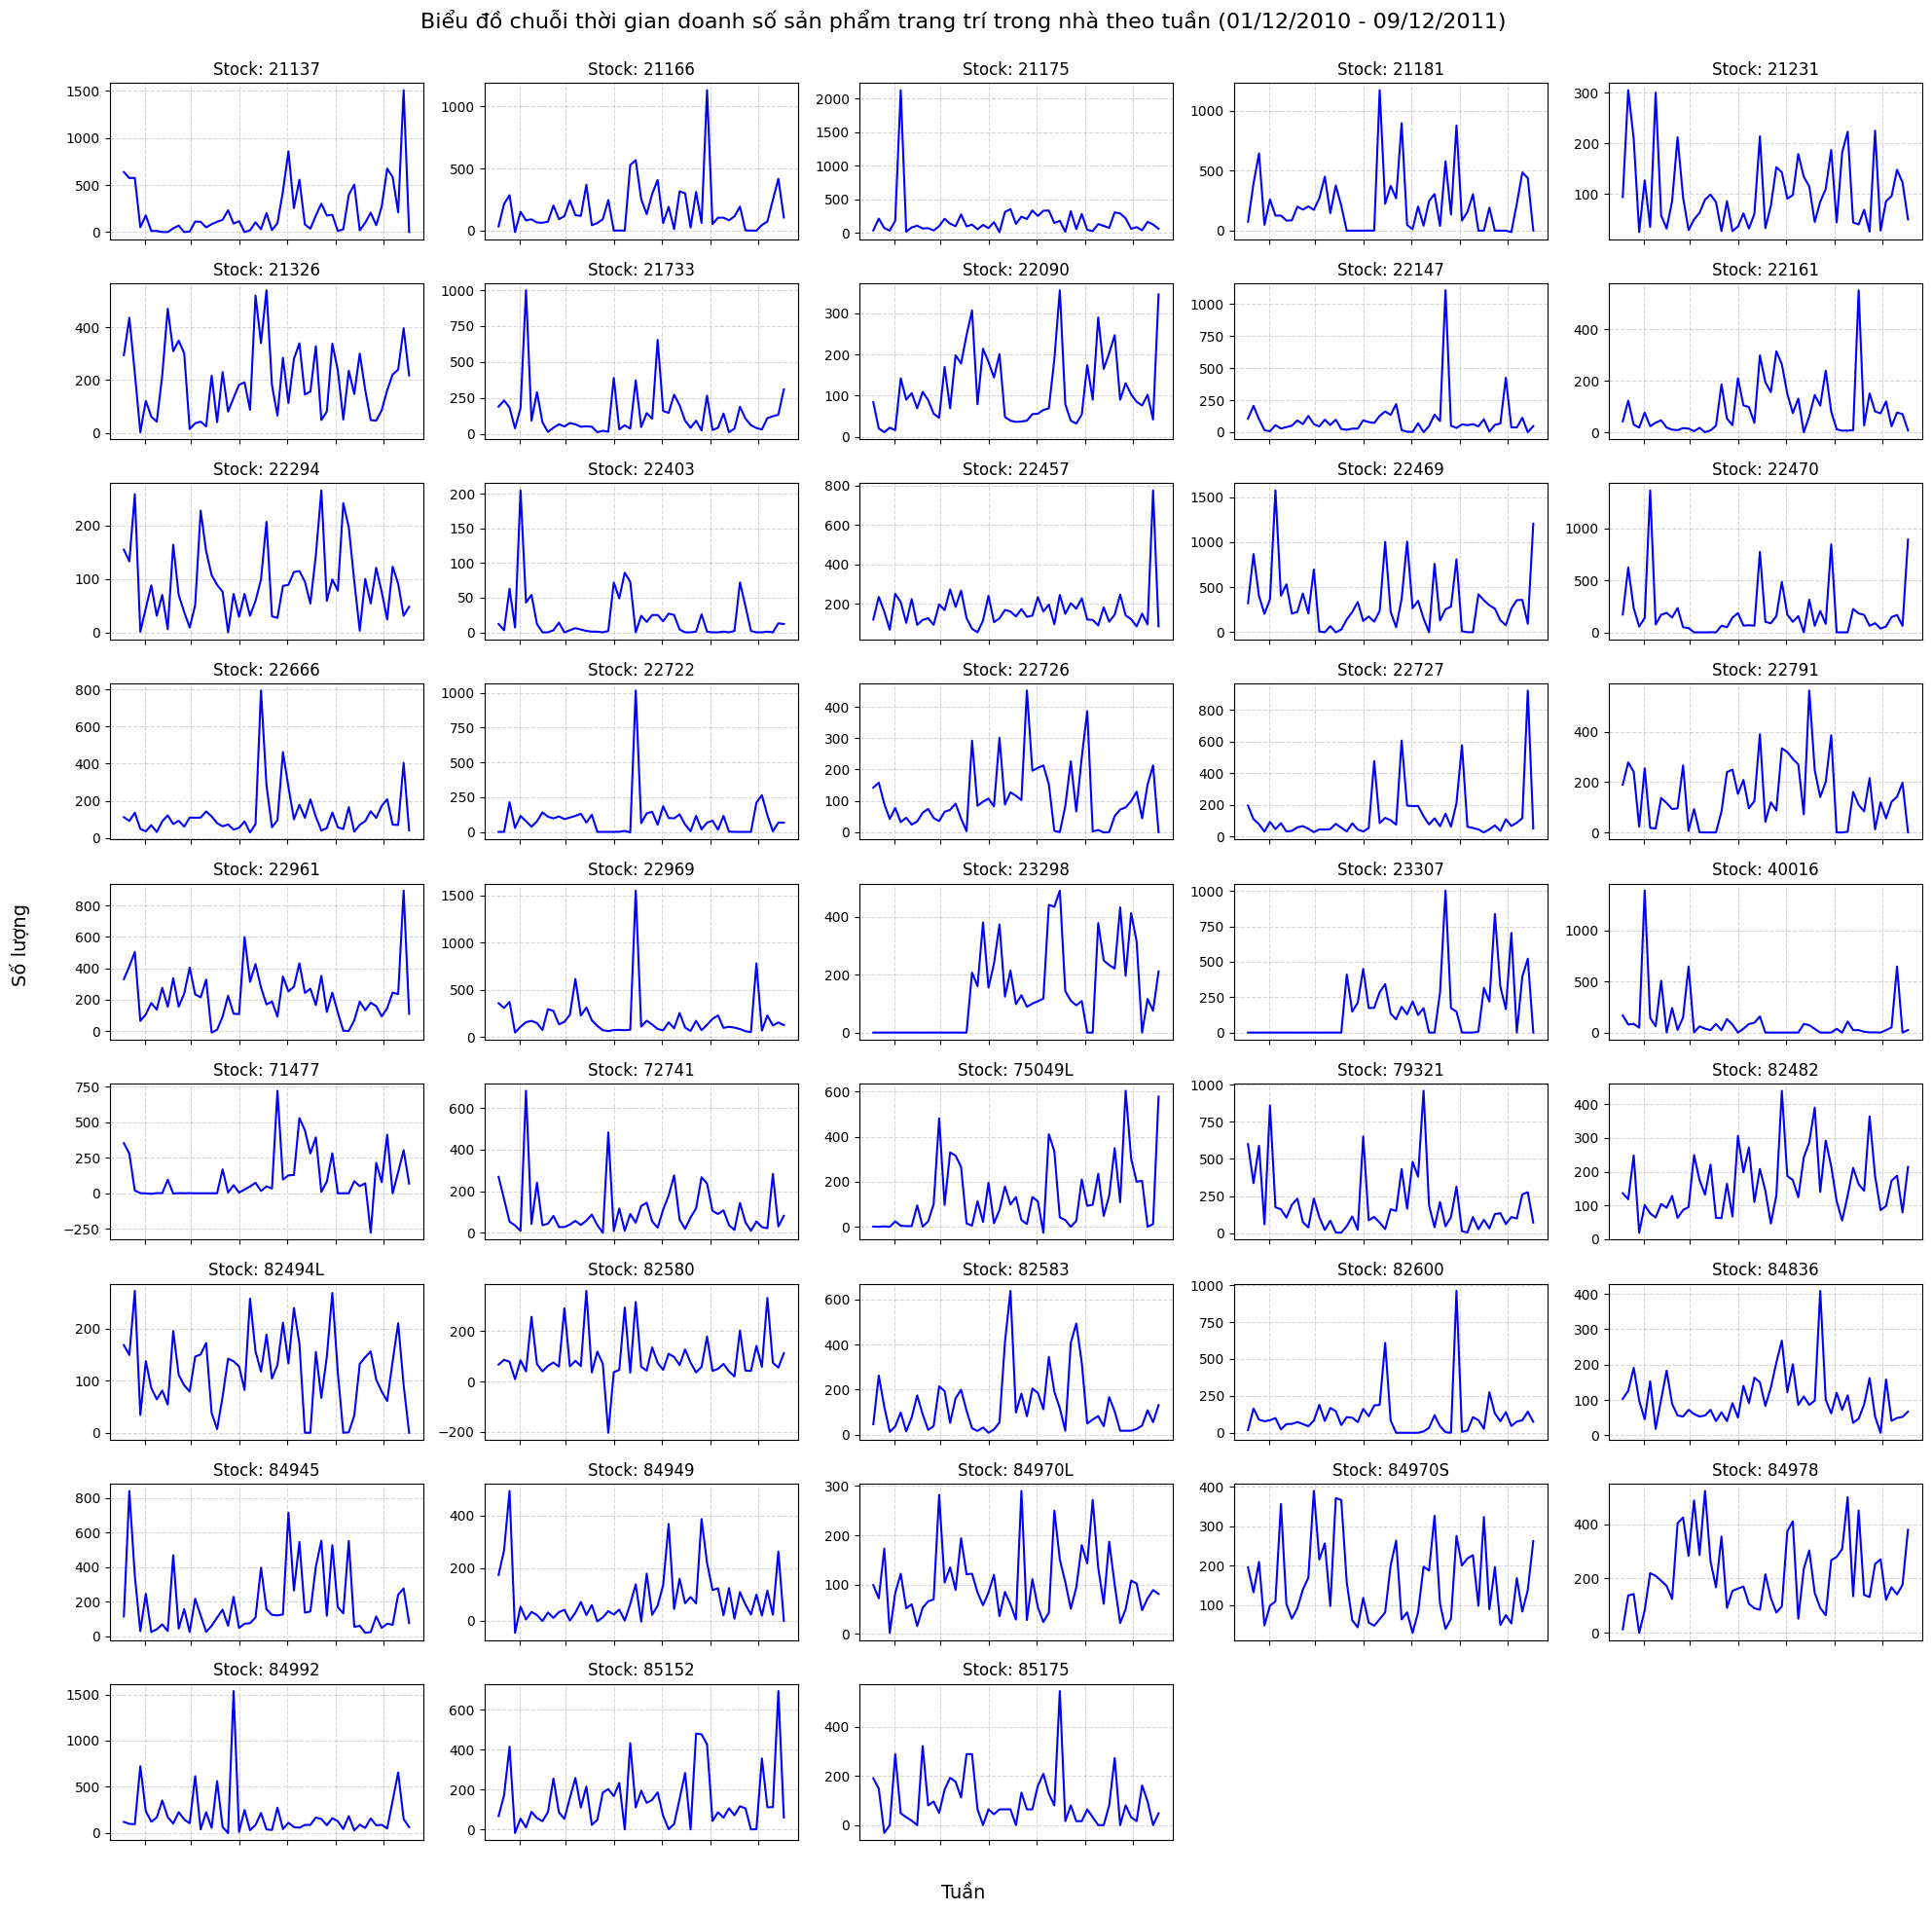

In [94]:
fig, axes = plt.subplots(nrows=9, ncols=5, figsize=(20, 20), sharex=True)
axes = axes.flatten()

for i, stock_code in enumerate(ts_data.columns):
    if i < 45:
        axes[i].plot(ts_data.index, ts_data[stock_code], color='blue', linewidth=1.5)
        axes[i].set_title(f"Stock: {stock_code}")
        axes[i].tick_params(axis='both', which='major')
        axes[i].grid(True, linestyle='--', alpha=0.5)
        axes[i].tick_params(axis='x', which='both', labelbottom=False)

for j in range(i + 1, len(axes)):
    axes[j].axis('off')

fig.text(0.5, 0.01, 'Tuần', ha='center', fontsize=14)
fig.text(0.01, 0.5, 'Số lượng', va='center', rotation='vertical', fontsize=14)

plt.suptitle("Biểu đồ chuỗi thời gian doanh số sản phẩm trang trí trong nhà theo tuần (01/12/2010 - 09/12/2011)", fontsize=16)
plt.tight_layout(rect=[0.03, 0.03, 1, 0.98])
plt.show()